In [1]:
import math
import time
import inspect
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F

In [2]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")
device_type = "cuda" if device.startswith("cuda") else "cpu"

using device: cuda


## GPT classes:

In [3]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu    = nn.GELU(approximate='tanh')
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and posisition embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)
        # forward the final layernorm and the classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x) # (B, T, vocab_size)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @classmethod
    def from_pretrained_hf(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

    def configure_optimizers(self, weight_decay, learning_rate, device_type):
        # start with all of the candidate parameters (that require grad)
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == "cuda"
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
        return optimizer


## Load stuff from google drive

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/Colab_Notebooks/gpt_checkpoints'
# log_file = os.path.join(save_dir, 'log.txt')

# with open(log_file, "r") as f:
#     log_lines = f.readlines()

# print(log_lines[:5])

Mounted at /content/drive


In [5]:
from collections import OrderedDict
def load_checkpoint(file_name="model_76291.pt"):
    checkpoint_path = os.path.join(save_dir, file_name)
    model = GPT(GPTConfig(vocab_size=50304))
    checkpoint = torch.load(checkpoint_path, map_location='cpu',weights_only=False)
    state_dict = checkpoint['model'] if 'model' in checkpoint else checkpoint

    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        # Remove the '_orig_mod.' prefix
        name = k.replace('_orig_mod.', '') 
        new_state_dict[name] = v

    model.load_state_dict(new_state_dict)
    return model

## Test generation from the model

In [6]:
import tiktoken
import numpy as np

enc = tiktoken.get_encoding("gpt2")

torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)


In [7]:
model = load_checkpoint()
model.to(device)

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50304, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50304, bias=False)
)

In [8]:
model.eval()
num_return_sequences = 2
max_length = 32
tokens = enc.encode("Hello, I'm a language model,")
tokens = torch.tensor(tokens, dtype=torch.long)
tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1)
xgen = tokens.to(device)
sample_rng = torch.Generator(device=device)
sample_rng.manual_seed(42)
while xgen.size(1) < max_length:
    # forward the model to get the logits
    with torch.no_grad():
        with torch.autocast(device_type=device_type, dtype=torch.bfloat16):
            logits, loss = model(xgen) # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        # note: multinomial does not demand the input to sum to 1
        ix = torch.multinomial(topk_probs, 1, generator=sample_rng) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        xgen = torch.cat((xgen, xcol), dim=1)
# print the generated text
for i in range(num_return_sequences):
    tokens = xgen[i, :max_length].tolist()
    decoded = enc.decode(tokens)
    print(f"sample {i}: {decoded}")


sample 0: Hello, I'm a language model, and I'll be able to talk about languages which are on the surface so far. And why are languages, and not
sample 1: Hello, I'm a language model, so i'm a little bit more
I have lots of stuff like some things like the code, etc that I want


## Evaluate HellaSwag

### HellaSwag helper functions

In [9]:

import json
import requests
from tqdm import tqdm
from transformers import GPT2LMHeadModel

# -----------------------------------------------------------------------------

DATA_CACHE_DIR = save_dir


def render_example(example):
    """
    Given the example as a dictionary, render it as three torch tensors:
    - tokens (the tokens of context + completion, of size 4xN, as there are always 4 candidates)
    - mask (is 1 in the region of the candidate completion, where we evaluate likelihoods)
    - label (the index of the correct completion, which we hope has the highest likelihood)
    """
    ctx = example["ctx"]
    label = example["label"]
    endings = example["endings"]

    # data needed to reproduce this eval on the C size
    data = {
        "label": label,
        "ctx_tokens": None,
        "ending_tokens": [],
    }

    # gather up all the tokens
    ctx_tokens = enc.encode(ctx)
    data["ctx_tokens"] = ctx_tokens
    tok_rows = []
    mask_rows = []
    for end in endings:
        end_tokens = enc.encode(" " + end) # note: prepending " " because GPT-2 tokenizer
        tok_rows.append(ctx_tokens + end_tokens)
        mask_rows.append([0]*len(ctx_tokens) + [1]*len(end_tokens))
        data["ending_tokens"].append(end_tokens)

    # have to be careful during the collation because the number of tokens in each row can differ
    max_len = max(len(row) for row in tok_rows)
    tokens = torch.zeros((4, max_len), dtype=torch.long)
    mask = torch.zeros((4, max_len), dtype=torch.long)
    for i, (tok_row, mask_row) in enumerate(zip(tok_rows, mask_rows)):
        tokens[i, :len(tok_row)] = torch.tensor(tok_row)
        mask[i, :len(mask_row)] = torch.tensor(mask_row)

    return data, tokens, mask, label

def iterate_examples(split='val'):
    # there are 10,042 examples in total in val
    with open(os.path.join(DATA_CACHE_DIR, f"hellaswag_{split}.jsonl"), "r") as f:
        for line in f:
            example = json.loads(line)
            yield example

# takes tokens, mask, and logits, returns the index of the completion with the lowest loss
def get_most_likely_row(tokens, mask, logits):
    # evaluate the autoregressive loss at all positions
    shift_logits = (logits[..., :-1, :]).contiguous()
    shift_tokens = (tokens[..., 1:]).contiguous()
    flat_shift_logits = shift_logits.view(-1, shift_logits.size(-1))
    flat_shift_tokens = shift_tokens.view(-1)
    shift_losses = F.cross_entropy(flat_shift_logits, flat_shift_tokens, reduction='none')
    shift_losses = shift_losses.view(tokens.size(0), -1)
    # now get the average loss just for the completion region (where mask == 1), in each row
    shift_mask = (mask[..., 1:]).contiguous() # we must shift mask, so we start at the last prompt token
    masked_shift_losses = shift_losses * shift_mask
    # sum and divide by the number of 1s in the mask
    sum_loss = masked_shift_losses.sum(dim=1)
    avg_loss = sum_loss / shift_mask.sum(dim=1)
    # now we have a loss for each of the 4 completions
    # the one with the lowest loss should be the most likely
    pred_norm = avg_loss.argmin().item()
    return pred_norm

@torch.no_grad()
def evaluate(model_type, device):

    torch.set_float32_matmul_precision('high') # use tf32
    model = GPT2LMHeadModel.from_pretrained(model_type)
    model.to(device)
    # model = torch.compile(model) # optionally torch compile the model

    num_correct_norm = 0
    num_correct = 0
    num_total = 0
    for example in iterate_examples("val"):
        data, tokens, mask, label = render_example(example)
        tokens = tokens.to(device)
        mask = mask.to(device)

        # get the logits
        logits = model(tokens).logits
        # evaluate the autoregressive loss at all positions
        shift_logits = (logits[..., :-1, :]).contiguous() # logits for next token
        shift_tokens = (tokens[..., 1:]).contiguous() # "next" tokens
        flat_shift_logits = shift_logits.view(-1, shift_logits.size(-1))
        flat_shift_tokens = shift_tokens.view(-1)
        shift_losses = F.cross_entropy(flat_shift_logits, flat_shift_tokens, reduction='none') # all 4 together, don't average yet
        shift_losses = shift_losses.view(tokens.size(0), -1) # reshape back to 4 choices
        # now get the average loss just for the completion region (where mask == 1), in each row
        shift_mask = (mask[..., 1:]).contiguous() # we must shift mask, so we start at the last prompt token
        masked_shift_losses = shift_losses * shift_mask
        # sum and divide by the number of 1s in the mask
        sum_loss = masked_shift_losses.sum(dim=1)
        avg_loss = sum_loss / shift_mask.sum(dim=1)
        # now we have a loss for each of the 4 completions
        # the one with the lowest loss should be the most likely
        pred = sum_loss.argmin().item()
        pred_norm = avg_loss.argmin().item()

        # accumulate stats
        num_total += 1
        num_correct += int(pred == label)
        num_correct_norm += int(pred_norm == label)
        print(f"{num_total} acc_norm: {num_correct_norm}/{num_total}={num_correct_norm/num_total:.4f}")

        # debug: pretty print a few examples, and the losses in each case
        if num_total < 10:
            print("---")
            print(f"Context:\n {example['ctx']}")
            print(f"Endings:")
            for i, end in enumerate(example["endings"]):
                print(f"{i} (loss: {avg_loss[i].item():.4f}) {end}")
            print(f"predicted: {pred_norm}, actual: {label}")

In [13]:
num_correct_norm = 0
num_total = 0
for i, example in enumerate(iterate_examples("val")):
    # render the example into tokens and labels
    _, tokens, mask, label = render_example(example)
    tokens = tokens.to(device)
    mask = mask.to(device)
    # get the logits
    with torch.no_grad():
        with torch.autocast(device_type=device_type, dtype=torch.bfloat16):
            logits, loss = model(tokens)
        pred_norm = get_most_likely_row(tokens, mask, logits)
    num_total += 1
    num_correct_norm += int(pred_norm == label)
    

acc_norm = num_correct_norm / num_total

print(f"HellaSwag accuracy: {num_correct_norm}/{num_total}={acc_norm:.4f}")



HellaSwag accuracy: 3316/10042=0.3302


## Plot results

In [25]:
# parse and visualize the logfile
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sz = "124M"

loss_baseline = {
    "124M": 3.2924,
}[sz]
hella2_baseline = { # HellaSwag for GPT-2
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]
hella3_baseline = { # HellaSwag for GPT-3
    "124M": 0.337,
    "350M": 0.436,
    "774M": 0.510,
    "1558M": 0.547,
}[sz]

my_hella = 0.3302

log_file = os.path.join(save_dir, 'log.txt')

with open(log_file, "r") as f:
    log_lines = f.readlines()

print(log_lines[:5])

hella_name = ['nanogpt-124M','gpt2-124M','gpt2-350M',"gpt2-774M", "gpt2-1558M", 'gpt3-124M','gpt3-350M',"gpt3-774M", "gpt3-1558M"]
hella_accu = [my_hella, 0.294463,0.375224,0.431986,0.488946,0.337,0.436,0.510,0.547]

['0 val 10.9519\n', '0 train 10.955008\n', '1 train 10.853450\n', '2 train 10.669430\n', '3 train 10.454096\n']


In [15]:
list_of_tules = [(1,3),(2,4),(5, 10)]
list(zip(*list_of_tules))


[(1, 2, 5), (3, 4, 10)]

Min Train Loss: 2.690241
Min Validation Loss: 2.9393


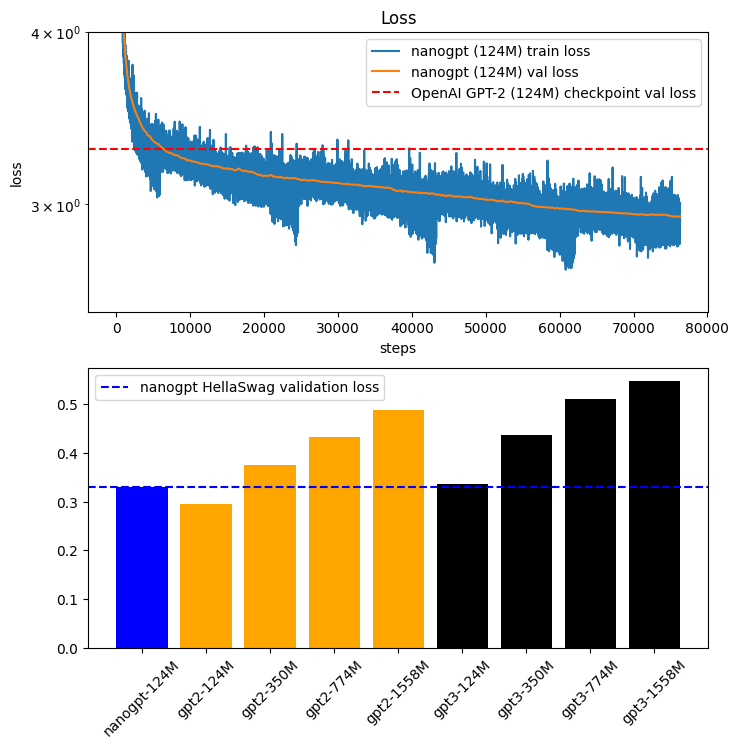

In [35]:


# parse the individual lines, group by stream (train,val,hella)
streams = {}
for line in log_lines:
    step, stream, val = line.strip().split()
    if stream not in streams:
        streams[stream] = {}
    streams[stream][int(step)] = float(val)

# convert each stream from {step: val} to (steps[], vals[])
# so it's easier for plotting
streams_xy = {}
for k, v in streams.items():
    # get all (step, val) items, sort them
    # k = 'val', 'train'
    # v = {0: 10.9519, 1: 10.9 ...}
    # v.items(): dict_items([(0, 10.9519), (250, 5.893), ...])
    xy = sorted(list(v.items())) # sort by step
    # unpack the list of tuples [(step,value),...] to [(steps...),(values...)]
    streams_xy[k] = list(zip(*xy))

# create figure
plt.figure(figsize=(8,8))

# Panel 1: losses: both train and val
plt.subplot(211)
xs, ys = streams_xy["train"] # training loss
ys = np.array(ys)
plt.plot(xs, ys, label=f'nanogpt ({sz}) train loss')
print("Min Train Loss:", min(ys))
xs, ys = streams_xy["val"] # validation loss
plt.plot(xs, ys, label=f'nanogpt ({sz}) val loss')
# horizontal line at GPT-2 baseline
if loss_baseline is not None:
    plt.axhline(y=loss_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale('log')
plt.ylim(top=4.0)
plt.legend()
plt.title("Loss")
print("Min Validation Loss:", min(ys))

plt.subplot(212)
bar_colors = ["blue"]+['orange']*4+['k']*4
plt.bar(hella_name, hella_accu,color=bar_colors)
plt.axhline(y=my_hella, color='blue', linestyle='--', label=f"nanogpt HellaSwag validation loss")
plt.xticks(rotation=45)
plt.legend()